# FINANCE 361 — Topic 16: Term Structure

**Instructor:** Dr. Zicheng (Leo) Xiao  
**Institution:** University of Auckland — FINANCE 361: Modern Investment Theory  
**Week:** 9

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Price a bond using a full term structure (yield curve) rather than a single rate.
2. Bootstrap a zero-coupon yield curve from observed coupon bond prices.
3. Derive quarterly forward rates from a spot curve using the no-arbitrage relationship.
4. Apply and interpret the z-spread as a market measure of credit risk.
5. Visualise how the yield curve shape (normal, flat, inverted) reflects market expectations.
6. Use real US Treasury data to construct and analyse an actual yield curve.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import brentq

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'

# ── Example term structure from the lecture ──────────────────────────────────
SPOT_TIMES  = np.array([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00])
SPOT_RATES  = np.array([0.020, 0.025, 0.027, 0.030, 0.032, 0.033, 0.034, 0.035])

# ── Spark example bond parameters ────────────────────────────────────────────
FACE  = 100.0
COUP  = 0.08      # annual coupon rate
FREQ  = 4         # quarterly
MAT   = 2.0       # years to maturity

---
## Section 1 — Bond Pricing with a Yield Curve

$$B_0 = \frac{F}{(1+r_T)^T} + \sum_{t \in K} \frac{C}{(1+r_t)^t}$$

### Predict-Then-Verify 1
> In Topic 15 we priced the Spark bond at **$105.85** using a flat rate of 5%. The term structure here has rates from 2% to 3.5% — all below 5%. Before running: will the price with this curve be higher or lower than $105.85? By roughly how much?

In [2]:
def discount_factors(times: np.ndarray, spot_rates: np.ndarray) -> np.ndarray:
    """Compute discount factors from spot rates."""
    return 1 / (1 + spot_rates) ** times


def bond_price_curve(F: float, c: float, T: float, freq: int,
                     times: np.ndarray, spot_rates: np.ndarray) -> float:
    """Price a coupon bond using a full spot rate curve."""
    delta = 1 / freq
    C = c * F * delta
    dfs = discount_factors(times, spot_rates)
    cfs = np.where(np.isclose(times, T), C + F, C)
    return float((cfs * dfs).sum())


price_curve = bond_price_curve(FACE, COUP, MAT, FREQ, SPOT_TIMES, SPOT_RATES)
price_flat5 = sum((FACE if np.isclose(t, MAT) else 0) / (1.05 ** t) +
                   COUP * FACE / FREQ / (1.05 ** t) for t in SPOT_TIMES)

print(f"Bond price (term structure):  ${price_curve:.4f}")
print(f"Bond price (flat r = 5%):     ${price_flat5:.4f}")
print(f"Difference:                   ${price_curve - price_flat5:.4f}")

# Pricing table
dfs = discount_factors(SPOT_TIMES, SPOT_RATES)
delta = 1 / FREQ
C = COUP * FACE * delta
cfs = np.where(np.isclose(SPOT_TIMES, MAT), C + FACE, C)

df_out = pd.DataFrame({
    't (years)':  SPOT_TIMES,
    'CF ($)':     cfs,
    'r_t':        SPOT_RATES,
    'd_t':        dfs.round(4),
    'PV(CF)':     (cfs * dfs).round(4)
})
print()
print(df_out.to_string(index=False))
print(f"\nTotal B0 = ${(cfs * dfs).sum():.4f}")

Bond price (term structure):  $108.7999
Bond price (flat r = 5%):     $105.8543
Difference:                   $2.9456

 t (years)  CF ($)   r_t    d_t  PV(CF)
      0.25     2.0 0.020 0.9951  1.9901
      0.50     2.0 0.025 0.9877  1.9755
      0.75     2.0 0.027 0.9802  1.9604
      1.00     2.0 0.030 0.9709  1.9417
      1.25     2.0 0.032 0.9614  1.9228
      1.50     2.0 0.033 0.9525  1.9049
      1.75     2.0 0.034 0.9432  1.8863
      2.00   102.0 0.035 0.9335 95.2181

Total B0 = $108.7999


---
## Section 2 — Visualising the Yield Curve

### Predict-Then-Verify 2
> The example term structure is upward-sloping. According to the Expectations Hypothesis, what does this imply about the market's expectation for future short-term interest rates? Write your prediction before plotting.

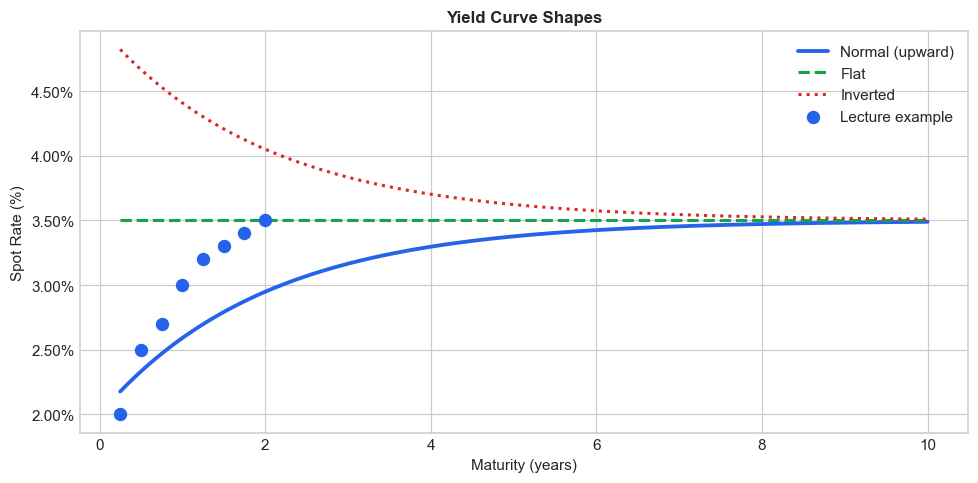

In [3]:
# Compare: normal, flat, and inverted yield curve shapes
t_grid = np.linspace(0.25, 10, 200)

def normal_curve(t):   return 0.02 + 0.015 * (1 - np.exp(-t / 2))
def flat_curve(t):     return np.full_like(t, 0.035)
def inverted_curve(t): return 0.05 - 0.015 * (1 - np.exp(-t / 2))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_grid, normal_curve(t_grid) * 100,   color='#2563eb', lw=2.5, label='Normal (upward)')
ax.plot(t_grid, flat_curve(t_grid) * 100,     color='#16a34a', lw=2.0, linestyle='--', label='Flat')
ax.plot(t_grid, inverted_curve(t_grid) * 100, color='#dc2626', lw=2.0, linestyle=':', label='Inverted')
ax.scatter(SPOT_TIMES, SPOT_RATES * 100, color='#2563eb', s=60, zorder=5, label='Lecture example')

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Spot Rate (%)')
ax.set_title('Yield Curve Shapes', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — Forward Rates

The no-arbitrage forward rate covering the interval $[t-\Delta,\, t]$:

$$r_{0,\, t-\Delta,\, t} = \left(\frac{(1+r_{0,0,t})^t}{(1+r_{0,0,t-\Delta})^{t-\Delta}}\right)^{1/\Delta} - 1$$

### Predict-Then-Verify 3
> The spot curve is upward-sloping (rates rise with maturity). Before computing: will the forward rates lie **above** or **below** the spot rates? Why?

In [4]:
def forward_rates(times: np.ndarray, spot_rates: np.ndarray) -> np.ndarray:
    """Compute implied forward rates between consecutive spot rate points."""
    delta = times[0]  # Assume uniform spacing = times[0]
    fwds  = np.empty_like(spot_rates)
    fwds[0] = spot_rates[0]   # First forward = first spot
    for i in range(1, len(times)):
        t   = times[i]
        t1  = times[i - 1]
        r   = spot_rates[i]
        r1  = spot_rates[i - 1]
        fwds[i] = ((1 + r) ** t / (1 + r1) ** t1) ** (1 / delta) - 1
    return fwds


fwds = forward_rates(SPOT_TIMES, SPOT_RATES)

df_fwd = pd.DataFrame({
    't (years)':   SPOT_TIMES,
    'Spot r(0,0,t)': (SPOT_RATES * 100).round(4),
    'Forward r(0,t-Δ,t)': (fwds * 100).round(4),
    'Check (1+f)^Δ': np.round((1 + fwds) ** 0.25, 4)
})
print(df_fwd.to_string(index=False))

# Verify: product of forward factors = spot factor at T=2
product = np.prod((1 + fwds) ** 0.25)
spot_fv = (1 + SPOT_RATES[-1]) ** SPOT_TIMES[-1]
print(f"\nProduct of forward factors: {product:.6f}")
print(f"(1 + r_2)^2 from spot:      {spot_fv:.6f}")
print("Match:", np.isclose(product, spot_fv))

 t (years)  Spot r(0,0,t)  Forward r(0,t-Δ,t)  Check (1+f)^Δ
      0.25            2.0              2.0000         1.0050
      0.50            2.5              3.0025         1.0074
      0.75            2.7              3.1012         1.0077
      1.00            3.0              3.9053         1.0096
      1.25            3.2              4.0039         1.0099
      1.50            3.3              3.8015         1.0094
      1.75            3.4              4.0020         1.0099
      2.00            3.5              4.2027         1.0103

Product of forward factors: 1.071225
(1 + r_2)^2 from spot:      1.071225
Match: True


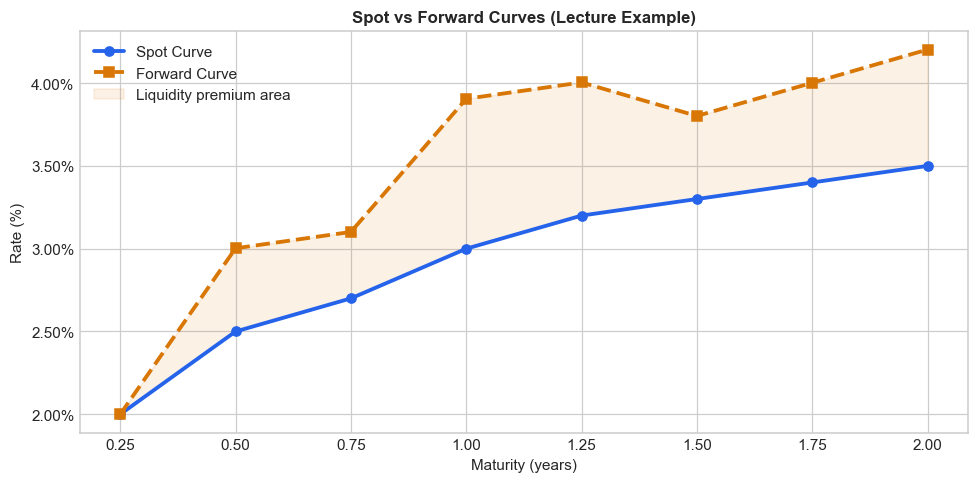

In [5]:
# Plot spot vs forward curve
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(SPOT_TIMES, SPOT_RATES * 100,  color='#2563eb', lw=2.5, marker='o', label='Spot Curve')
ax.plot(SPOT_TIMES, fwds * 100,        color='#d97706', lw=2.5, marker='s',
        linestyle='--', label='Forward Curve')
ax.fill_between(SPOT_TIMES, SPOT_RATES * 100, fwds * 100,
                alpha=0.10, color='#d97706', label='Liquidity premium area')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Rate (%)')
ax.set_title('Spot vs Forward Curves (Lecture Example)', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4 — z-Spread: Pricing Credit Risky Bonds

$$M_0 = \frac{F}{(1+r_T+z)^T} + \sum_{t \in K} \frac{C}{(1+r_t+z)^t}$$

### Predict-Then-Verify 4
> A bond with a z-spread of 170bp is a _credit-risky_ version of the Spark bond. The risk-free price is $108.80. Before computing: by roughly how many dollars will the risky bond be cheaper? Think about what 170bp means for each discount factor.

In [6]:
def bond_price_zspread(F, c, T, freq, times, spot_rates, z):
    """Price a bond with a given z-spread applied to the spot curve."""
    adjusted = spot_rates + z
    return bond_price_curve(F, c, T, freq, times, adjusted)


def solve_zspread(F, c, T, freq, times, spot_rates, market_price):
    """Solve for the z-spread given a market price."""
    def obj(z):
        return bond_price_zspread(F, c, T, freq, times, spot_rates, z) - market_price
    return brentq(obj, -0.10, 5.0)


rf_price = bond_price_curve(FACE, COUP, MAT, FREQ, SPOT_TIMES, SPOT_RATES)
z = 0.017  # 170bp
risky_price = bond_price_zspread(FACE, COUP, MAT, FREQ, SPOT_TIMES, SPOT_RATES, z)

print(f"Risk-free bond price (z=0):   ${rf_price:.4f}")
print(f"Risky bond price (z=170bp):   ${risky_price:.4f}")
print(f"Credit discount:              ${risky_price - rf_price:.4f}")

# Pricing table with z-spread
adj_rates = SPOT_RATES + z
dfs_z = discount_factors(SPOT_TIMES, adj_rates)
delta = 1 / FREQ
C = COUP * FACE * delta
cfs = np.where(np.isclose(SPOT_TIMES, MAT), C + FACE, C)

df_z = pd.DataFrame({
    't':      SPOT_TIMES,
    'CF':     cfs,
    'r_t':    (SPOT_RATES * 100).round(1),
    'r_t+z':  (adj_rates * 100).round(1),
    'd_t':    dfs_z.round(4),
    'PV(CF)': (cfs * dfs_z).round(4)
})
print()
print(df_z.to_string(index=False))
print(f"\nTotal M0 = ${(cfs * dfs_z).sum():.4f}")

Risk-free bond price (z=0):   $108.7999
Risky bond price (z=170bp):   $105.5295
Credit discount:              $-3.2704

   t    CF  r_t  r_t+z    d_t  PV(CF)
0.25   2.0  2.0    3.7 0.9910  1.9819
0.50   2.0  2.5    4.2 0.9796  1.9593
0.75   2.0  2.7    4.4 0.9682  1.9364
1.00   2.0  3.0    4.7 0.9551  1.9102
1.25   2.0  3.2    4.9 0.9420  1.8839
1.50   2.0  3.3    5.0 0.9294  1.8589
1.75   2.0  3.4    5.1 0.9166  1.8333
2.00 102.0  3.5    5.2 0.9036 92.1656

Total M0 = $105.5295


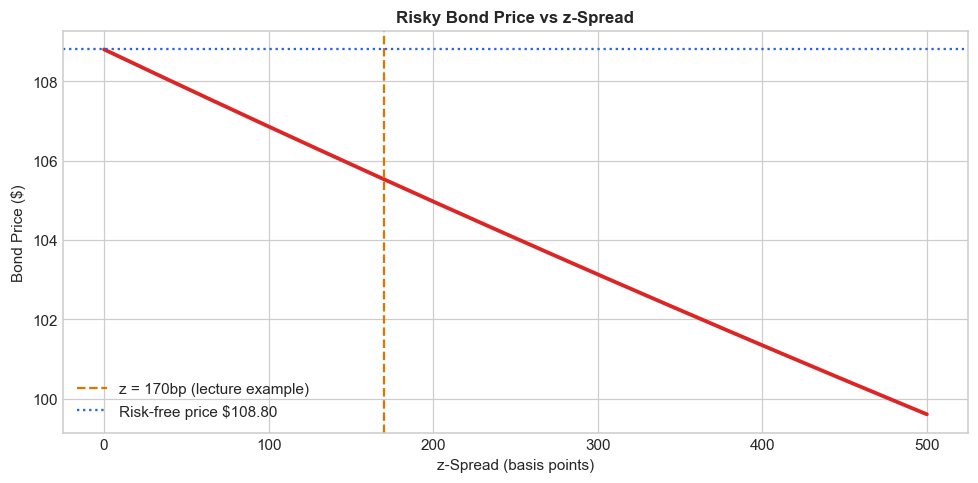

In [7]:
# Bond price vs z-spread
z_values = np.linspace(0, 0.05, 200)
prices   = [bond_price_zspread(FACE, COUP, MAT, FREQ, SPOT_TIMES, SPOT_RATES, z_) for z_ in z_values]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(z_values * 10000, prices, color='#dc2626', lw=2.5)
ax.axvline(170, color='#d97706', lw=1.5, linestyle='--', label='z = 170bp (lecture example)')
ax.axhline(rf_price, color='#2563eb', lw=1.5, linestyle=':', label=f'Risk-free price ${rf_price:.2f}')
ax.set_xlabel('z-Spread (basis points)')
ax.set_ylabel('Bond Price ($)')
ax.set_title('Risky Bond Price vs z-Spread', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 5 — Real Data: US Treasury Yield Curve

Download real Treasury yields using `pandas_datareader` from FRED and plot the actual yield curve on two dates: a recent date (normal curve) and a past inverted date.

### Predict-Then-Verify 5
> The US yield curve inverted around 2022–2023 as the Fed raised rates aggressively. Before running: on the inverted date, do you expect the 2-year or the 10-year yield to be higher?

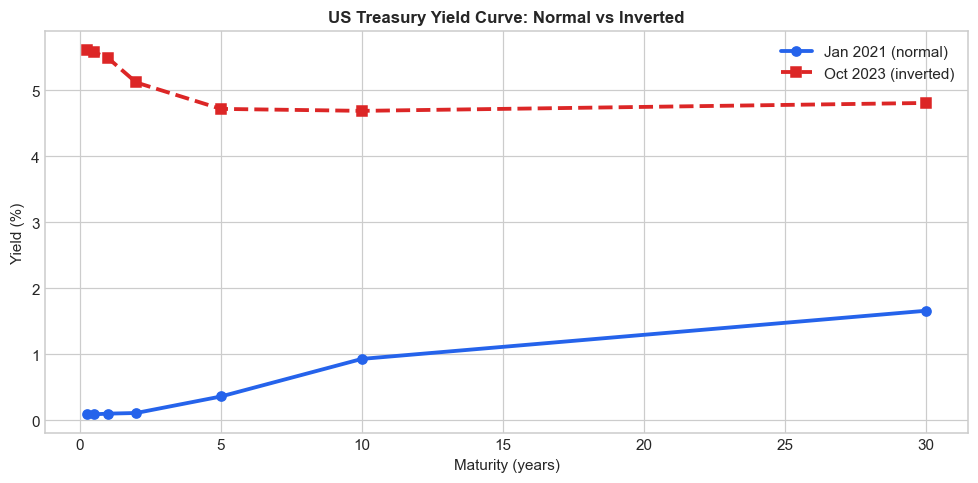

Jan 2021 (normal curve):
{'3M': np.float64(0.09), '6M': np.float64(0.09), '1Y': np.float64(0.1), '2Y': np.float64(0.11), '5Y': np.float64(0.36), '10Y': np.float64(0.93), '30Y': np.float64(1.66)}
Oct 2023 (inverted curve):
{'3M': np.float64(5.62), '6M': np.float64(5.58), '1Y': np.float64(5.49), '2Y': np.float64(5.12), '5Y': np.float64(4.72), '10Y': np.float64(4.69), '30Y': np.float64(4.81)}


In [8]:
try:
    import pandas_datareader.data as web

    # Treasury constant maturity yields from FRED
    SERIES = {
        '3M': 'DGS3MO', '6M': 'DGS6MO', '1Y': 'DGS1',
        '2Y': 'DGS2',   '5Y': 'DGS5',   '10Y': 'DGS10', '30Y': 'DGS30'
    }
    MATURITIES = [0.25, 0.5, 1, 2, 5, 10, 30]  # years

    raw = web.DataReader(list(SERIES.values()), 'fred', start='2020-01-01', end='2024-12-31')
    raw.columns = list(SERIES.keys())

    # Pick two dates: normal (Jan 2021) and inverted (Oct 2023)
    date_normal   = raw.loc['2021-01-04'].values
    date_inverted = raw.loc['2023-10-02'].values

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(MATURITIES, date_normal,   color='#2563eb', lw=2.5, marker='o', label='Jan 2021 (normal)')
    ax.plot(MATURITIES, date_inverted, color='#dc2626', lw=2.5, marker='s', linestyle='--',
            label='Oct 2023 (inverted)')
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Yield (%)')
    ax.set_title('US Treasury Yield Curve: Normal vs Inverted', fontsize=11, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Jan 2021 (normal curve):")
    print(dict(zip(SERIES.keys(), date_normal.round(2))))
    print("Oct 2023 (inverted curve):")
    print(dict(zip(SERIES.keys(), date_inverted.round(2))))

except Exception as e:
    print(f"pandas_datareader not available or network error: {e}")
    print("Install with: pip install pandas-datareader")
    print("Alternatively, download CSVs from https://fred.stlouisfed.org/")

---
## Section 6 — Challenge: Bootstrapping a Zero Curve and Pricing

Given three annual coupon bonds with known market prices, bootstrap the 1-year, 2-year, and 3-year zero rates, then price a new bond using these zero rates.

In [9]:
# Observed market prices of three annual coupon bonds (F=100)
MARKET = [
    {'T': 1, 'c': 0.04, 'price': 98.10},   # 1-year, 4% coupon
    {'T': 2, 'c': 0.05, 'price': 99.60},   # 2-year, 5% coupon
    {'T': 3, 'c': 0.06, 'price': 101.30},  # 3-year, 6% coupon
]

# Bootstrap zero rates
zero_rates = {}

# Year 1: only one cash flow at T=1
p1  = MARKET[0]['price']
cf1 = (1 + MARKET[0]['c']) * 100
d1  = p1 / cf1
z1  = 1 / d1 - 1
zero_rates[1] = z1

# Year 2: coupon at T=1 + coupon+principal at T=2
c2  = MARKET[1]['c'] * 100
p2  = MARKET[1]['price']
d2  = (p2 - c2 * d1) / (100 + c2)
z2  = d2 ** (-0.5) - 1
zero_rates[2] = z2

# Year 3: coupons at T=1,2 + coupon+principal at T=3
c3  = MARKET[2]['c'] * 100
p3  = MARKET[2]['price']
d3  = (p3 - c3 * d1 - c3 * d2) / (100 + c3)
z3  = d3 ** (-1/3) - 1
zero_rates[3] = z3

print("=== Bootstrapped Zero Rates ===")
for T, z in zero_rates.items():
    print(f"  z({T}) = {z:.4%}")

# Price a new 3-year, 5% annual coupon bond using bootstrapped curve
dfs_boot = {1: d1, 2: d2, 3: d3}
new_bond_price = 5 * d1 + 5 * d2 + 105 * d3
print(f"\nNew bond (3yr, 5% annual): ${new_bond_price:.4f}")

=== Bootstrapped Zero Rates ===
  z(1) = 6.0143%
  z(2) = 5.1959%
  z(3) = 5.5205%

New bond (3yr, 5% annual): $98.6020


---
## Section 7 — Reflect: Explain to Teach

Answer the following questions in your own words (without AI), 2–3 sentences each.

1. **Why can't we use the annuity formula when pricing bonds with a term structure?** Give a concrete numerical reason, not just "the rates are different".

2. **A colleague says: "The forward rate r(0, 1, 2) tells us what the 1-year rate will be next year." Is this correct?** Explain the distinction between a forward rate and an expected future spot rate.

3. **The z-spread is described as a "parallel shift" to the risk-free curve. What does the word 'parallel' mean here?** Why is a parallel shift a simplification — in what sense might the credit spread vary across maturities?

4. **Look at the bootstrapped zero rates in Section 6. Compare them with the coupon bond YTMs.** Explain, intuitively, why a 5% 3-year bond's YTM does not equal the 3-year zero rate.

*Write your answers here:*

1. 

2. 

3. 

4. 

---
## Extension: Going Further

- **Nelson-Siegel model:** Fit a smooth yield curve to observed Treasury yields using the parametric Nelson-Siegel form. The three parameters have intuitive interpretations: level, slope, and curvature.
- **Credit transition matrix:** Download Moody's historical transition data and simulate the credit quality of a portfolio over 5 years using a Markov chain.
- **CDS pricing:** Implement a simple reduced-form CDS pricing model using the hazard rate framework — show how the fair CDS spread relates to the bond's z-spread.
- **Yield curve and recession prediction:** Replicate the Estrella-Mishkin (1998) logit model predicting US recessions from the 10y–3m spread using data from FRED.